In [3]:
import pandas as pd
import re
import string
import numpy as np
import torch
import torch.nn as nn


from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mrsikandarali/balanced-dataset-metahate/balanced_dataset.csv


In [5]:
df = pd.read_csv("/kaggle/input/datasets/mrsikandarali/balanced-dataset-metahate/balanced_dataset.csv")
print(df.head())

   label                                               text
0      1  "@Blackman38Tide: @WhaleLookyHere @HowdyDowdy1...
1      1  "@CB_Baby24: @white_thunduh alsarabsss" hes a ...
2      1  "@DevilGrimz: @VigxRArts you're fucking gay, b...
3      1  "@MarkRoundtreeJr: LMFAOOOO I HATE BLACK PEOPL...
4      1  "@NoChillPaz: "At least I'm not a nigger" http...


In [6]:
texts = df['text'].astype(str)
labels = df['label']

# show updated dataset
print(df.head())
print("Dataset shape:", df.shape)

   label                                               text
0      1  "@Blackman38Tide: @WhaleLookyHere @HowdyDowdy1...
1      1  "@CB_Baby24: @white_thunduh alsarabsss" hes a ...
2      1  "@DevilGrimz: @VigxRArts you're fucking gay, b...
3      1  "@MarkRoundtreeJr: LMFAOOOO I HATE BLACK PEOPL...
4      1  "@NoChillPaz: "At least I'm not a nigger" http...
Dataset shape: (466578, 2)


# Preprocessing steps

In [7]:
def clean_text(text):
    text = text.lower()                        # lowercase
    text = re.sub(r"http\S+", "", text)        # remove URLs
    text = re.sub(r"@\w+", "", text)           # remove mentions
    text = re.sub(r"#\w+", "", text)           # remove hashtags
    text = re.sub(r"[^a-zA-Z\s]", "", text)    # remove special chars
    text = re.sub(r"\s+", " ", text).strip()   # remove extra spaces
    return text

texts = texts.apply(clean_text)

In [8]:
# Train test split 
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.1, random_state=42, stratify=labels
)

### Tokenization (Convert words → numbers)

In [9]:
MAX_VOCAB = 50000

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [10]:
# Padding (Make same length sequences)
MAX_LEN = 100  # you can tune (e.g., 128)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# Convert to PyTorch Tensors


X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)


# Create Dataset + 



train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)


# imports for GRU

In [11]:
# GPU Optimization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# GRU Model (Optimized)
# Includes: Embedding layer, Bidirectional GRU, Dropout (avoid overfitting) and Fully connected layer

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(GRUModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        
        self.dropout = nn.Dropout(0.3)
        
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        x = self.embedding(x)                      # (batch, seq_len, embed_dim)
        
        _, hidden = self.gru(x)                    # hidden shape: (2, batch, hidden_dim)
        
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # bidirectional
        
        x = self.dropout(hidden)
        
        return self.fc(x)

Using device: cuda


### Hyperparameters (Tuned for Large Data)

In [12]:
VOCAB_SIZE = 50000
EMBED_DIM = 128
HIDDEN_DIM = 128
OUTPUT_DIM = 2   # change if multiclass

BATCH_SIZE = 256   # larger batch for GPU
EPOCHS = 5
LR = 1e-3

## Model Initialization

In [13]:
model = GRUModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM)
model = model.to(device)

# Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

#DataLoader (IMPORTANT for speed)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=4,
    pin_memory=True
)

### Training Loop (Optimized)

In [14]:
 from tqdm import tqdm

for epoch in range(EPOCHS):
    
    model.train()
    total_loss = 0
    
    for inputs, labels in tqdm(train_loader):
        
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        # Gradient clipping (important for GRU stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 1641/1641 [00:27<00:00, 60.27it/s]


Epoch 1, Loss: 0.4395


100%|██████████| 1641/1641 [00:26<00:00, 62.83it/s]


Epoch 2, Loss: 0.3643


100%|██████████| 1641/1641 [00:26<00:00, 61.23it/s]


Epoch 3, Loss: 0.3325


100%|██████████| 1641/1641 [00:27<00:00, 59.14it/s]


Epoch 4, Loss: 0.3025


100%|██████████| 1641/1641 [00:28<00:00, 57.63it/s]

Epoch 5, Loss: 0.2719


## evalvation

In [15]:

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8408
Precision: 0.8415
Recall   : 0.8408
F1 Score : 0.8407


In [32]:
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))


Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.82      0.84     23329
           1       0.83      0.86      0.84     23329

    accuracy                           0.84     46658
   macro avg       0.84      0.84      0.84     46658
weighted avg       0.84      0.84      0.84     46658



In [16]:
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[19081  4248]
 [ 3180 20149]]


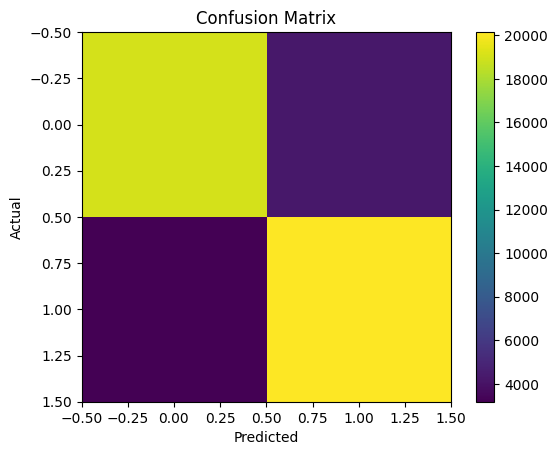

In [17]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()